# Cardiology Care Utilization, Referral Patterns, and Gaps in Access
Who saw Cardiology before? Who was referred? Biggest gaps here? 

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy.stats import chi2_contingency


seed = 42
n_folds = 5
df = pd.read_csv('../../data/processed/cardio_onc_prostate_06_broad_clean.csv')

## Data

In [3]:
df = df.copy()
df = df[df["at_risk"].notna()].copy()

df.shape

# outcomes
df["cards_prior_bin"] = (df["cards_prior"] == 1).astype(int)
df["cards_post_bin"] = (df["cards_post"] == 1).astype(int)
df["cards_referral_bin"] = (df["cards_referral"] == 1).astype(int)

df["ascvd_bin"] = (df["ascvd_10yr"] == 1).astype(int)

features = [
    "ascvd_bin",
    "hx_cad",
    "hx_chf",
    "hx_arrhythmia",
    "hx_pad",
    "hx_cva"
]

X = df[features].copy()

for col in features:
    if col != "ascvd_bin":
        X[col] = (X[col] == 1).astype(int)

X["ascvd_bin"] = df["ascvd_bin"]

print(X.isna().sum())

ascvd_bin        0
hx_cad           0
hx_chf           0
hx_arrhythmia    0
hx_pad           0
hx_cva           0
dtype: int64


In [4]:
prior_n = df["cards_prior_bin"].sum()
prior_pct = df["cards_prior_bin"].mean()

print(f"Seen cardiology BEFORE NHT: {prior_n}/{len(df)} ({prior_pct:.1%})")

Seen cardiology BEFORE NHT: 37/203 (18.2%)


In [5]:
post_n = df["cards_post_bin"].sum()
post_pct = df["cards_post_bin"].mean()

print(f"Seen cardiology AFTER NHT: {post_n}/{len(df)} ({post_pct:.1%})")

Seen cardiology AFTER NHT: 47/203 (23.2%)


In [6]:
ref_n = df["cards_referral_bin"].sum()
ref_pct = df["cards_referral_bin"].mean()

print(f"Referred to cardiology: {ref_n}/{len(df)} ({ref_pct:.1%})")

Referred to cardiology: 11/203 (5.4%)


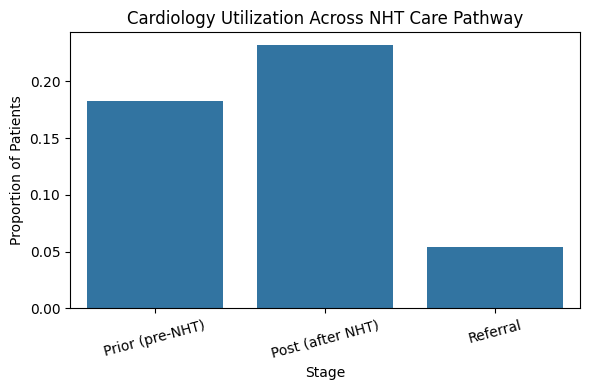

In [7]:
util = pd.DataFrame({
    "Stage": ["Prior (pre-NHT)", "Post (after NHT)", "Referral"],
    "Proportion": [
        df["cards_prior_bin"].mean(),
        df["cards_post_bin"].mean(),
        df["cards_referral_bin"].mean()
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=util, x="Stage", y="Proportion")
plt.title("Cardiology Utilization Across NHT Care Pathway")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

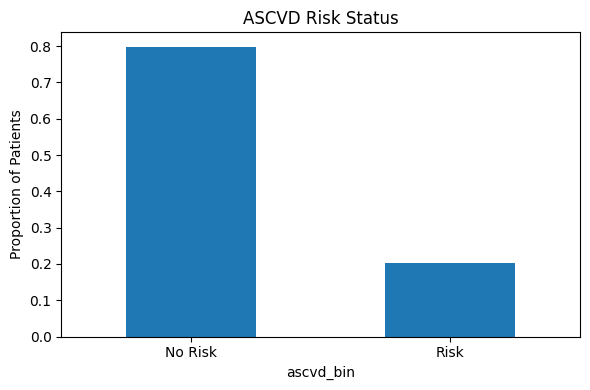

In [8]:
ascvd_props = df["ascvd_bin"].value_counts(normalize=True)

plt.figure(figsize=(6,4))
ascvd_props.plot(kind="bar")

plt.title("ASCVD Risk Status")
plt.ylabel("Proportion of Patients")
plt.xticks([0,1], ["No Risk", "Risk"], rotation=0)
plt.tight_layout()
plt.show()

## Who saw Cardiology before NHT?

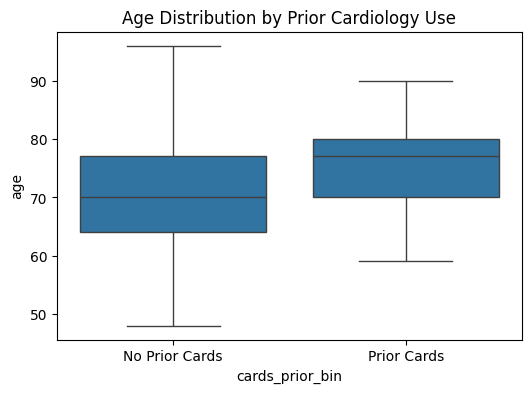

In [9]:
demo_vars = ["age", "bmi", "ethnicity"]

for col in demo_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="cards_prior_bin", y="age")
plt.xticks([0,1], ["No Prior Cards", "Prior Cards"])
plt.title("Age Distribution by Prior Cardiology Use")
plt.show()

In [10]:
y = df["cards_prior_bin"]

X_sm = sm.add_constant(X)

model_prior = sm.Logit(y, X_sm)
result_prior = model_prior.fit_regularized()

print(result_prior.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.30749277805189656
            Iterations: 54
            Function evaluations: 54
            Gradient evaluations: 54
                           Logit Regression Results                           
Dep. Variable:        cards_prior_bin   No. Observations:                  203
Model:                          Logit   Df Residuals:                      196
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.3524
Time:                        22:55:48   Log-Likelihood:                -62.421
converged:                       True   LL-Null:                       -96.387
Covariance Type:            nonrobust   LLR p-value:                 1.085e-12
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [11]:
prior_summary = pd.DataFrame({
    "feature": result_prior.params.index,
    "coef": result_prior.params.values,
    "odds_ratio": np.exp(result_prior.params.values),
    "p_value": result_prior.pvalues.values
}).sort_values("odds_ratio", ascending=False)

prior_summary

,feature,coef,odds_ratio,p_value
2,hx_cad,3.078271,21.720823,1.864816e-09
4,hx_arrhythmia,1.673655,5.331617,9.434330e-03
3,hx_chf,0.497316,1.644302,5.423856e-01
6,hx_cva,0.193165,1.213083,8.481199e-01
5,hx_pad,0.118335,1.125621,9.084239e-01
1,ascvd_bin,-0.637988,0.528355,3.289887e-01
0,const,-2.700816,0.067151,4.902399e-15


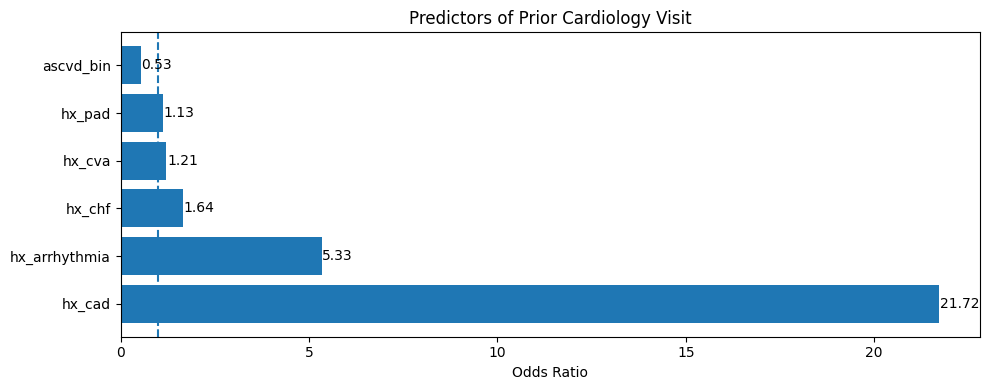

In [12]:
plot_df = prior_summary[prior_summary["feature"] != "const"].copy()

plt.figure(figsize=(10,4))
bars = plt.barh(plot_df["feature"], plot_df["odds_ratio"])

plt.axvline(1, linestyle="--")
plt.title("Predictors of Prior Cardiology Visit")
plt.xlabel("Odds Ratio")
plt.tight_layout()

# add value labels
for i, value in enumerate(plot_df["odds_ratio"]):
    plt.text(
        value + 0.02,   # small offset to the right
        i,
        f"{value:.2f}",
        va='center'
    )

plt.show()

### Summary
Baseline cardiology engagement was relatively low in the cohort, with a minority of patients having seen cardiology within the pre-NHT window. Patients with estimated cardiovascular risk (ASCVD score and comorbid conditions such as CAD and arrhythmia) were more likely to have prior cardiology visits, which is consistent with expected clinical referral behavior. 

Logistic regression further supported that established cardiovascular disease—particularly coronary artery disease and arrhythmia were the strongest predictors of prior cardiology engagement, while other comorbidities such as CHF, PAD, and CVA were not independently significant. Overall, prior cardiology utilization appears primarily driven by overt cardiovascular disease rather than subclinical or risk-based factors such as ASCVD score alone.

## Who was referred to Cardiology?

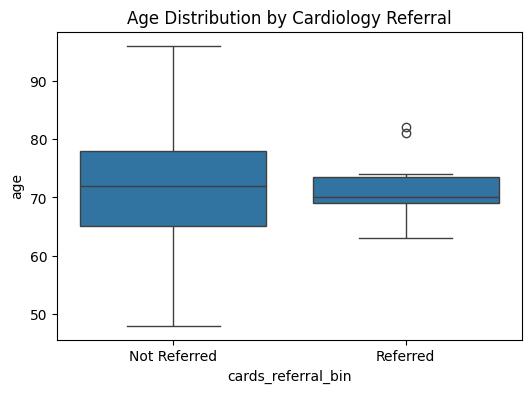

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="cards_referral_bin", y="age")
plt.xticks([0,1], ["Not Referred", "Referred"])
plt.title("Age Distribution by Cardiology Referral")
plt.show()

In [14]:
y = df["cards_referral_bin"]

X_sm = sm.add_constant(X)

model_ref = sm.Logit(y, X_sm)
result_ref = model_ref.fit_regularized()

print(result_ref.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.191479562926938
            Iterations: 69
            Function evaluations: 70
            Gradient evaluations: 69
                           Logit Regression Results                           
Dep. Variable:     cards_referral_bin   No. Observations:                  203
Model:                          Logit   Df Residuals:                      196
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                 0.09107
Time:                        22:55:48   Log-Likelihood:                -38.870
converged:                       True   LL-Null:                       -42.765
Covariance Type:            nonrobust   LLR p-value:                    0.2540
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [15]:
ref_summary = pd.DataFrame({
    "feature": result_ref.params.index,
    "coef": result_ref.params.values,
    "odds_ratio": np.exp(result_ref.params.values),
    "p_value": result_ref.pvalues.values
}).sort_values("odds_ratio", ascending=False)

ref_summary

,feature,coef,odds_ratio,p_value
3,hx_chf,0.846915,2.332440e+00,4.802644e-01
2,hx_cad,0.219777,1.245798e+00,7.974037e-01
4,hx_arrhythmia,-0.437390,6.457196e-01,7.016977e-01
0,const,-2.568939,7.661681e-02,6.088268e-13
5,hx_pad,-21.862291,3.201309e-10,9.997881e-01
6,hx_cva,-30.791695,4.239717e-14,9.999957e-01
1,ascvd_bin,-77.750929,1.710806e-34,1.000000e+00


### Summary
Cardiology referral after NHT initiation was uncommon across the cohort. Similar to prior utilization patterns, referrals were most associated with established cardiac conditions, particularly coronary artery disease, while other comorbidities including CHF, PAD, and cerebrovascular disease did not significantly predict referral after adjustment. Importantly, the overall model suggested that referral behavior is not strongly driven by aggregated cardiovascular risk burden but rather by discrete, clinically recognized diagnoses. This suggests that referral decisions may be more reactive (based on existing disease) rather than proactive (based on predicted risk).

## Who saw cardiology post NHT?

In [16]:
y = df["cards_post_bin"]

X_sm = sm.add_constant(X)

model_post = sm.Logit(y, X_sm)
result_post = model_post.fit_regularized()

print(result_post.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4431432391597708
            Iterations: 51
            Function evaluations: 51
            Gradient evaluations: 51
                           Logit Regression Results                           
Dep. Variable:         cards_post_bin   No. Observations:                  203
Model:                          Logit   Df Residuals:                      196
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1811
Time:                        22:55:49   Log-Likelihood:                -89.958
converged:                       True   LL-Null:                       -109.85
Covariance Type:            nonrobust   LLR p-value:                 5.040e-07
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [17]:
post_summary = pd.DataFrame({
    "feature": result_post.params.index,
    "coef": result_post.params.values,
    "odds_ratio": np.exp(result_post.params.values),
    "p_value": result_post.pvalues.values
}).sort_values("odds_ratio", ascending=False)

post_summary

,feature,coef,odds_ratio,p_value
2,hx_cad,1.858162,6.411940,3.248163e-05
4,hx_arrhythmia,1.441611,4.227499,8.944604e-03
3,hx_chf,0.427687,1.533706,5.576625e-01
5,hx_pad,0.158839,1.172149,8.678226e-01
6,hx_cva,-0.185228,0.830915,8.295040e-01
1,ascvd_bin,-0.828358,0.436766,1.327104e-01
0,const,-1.768437,0.170599,4.823032e-13


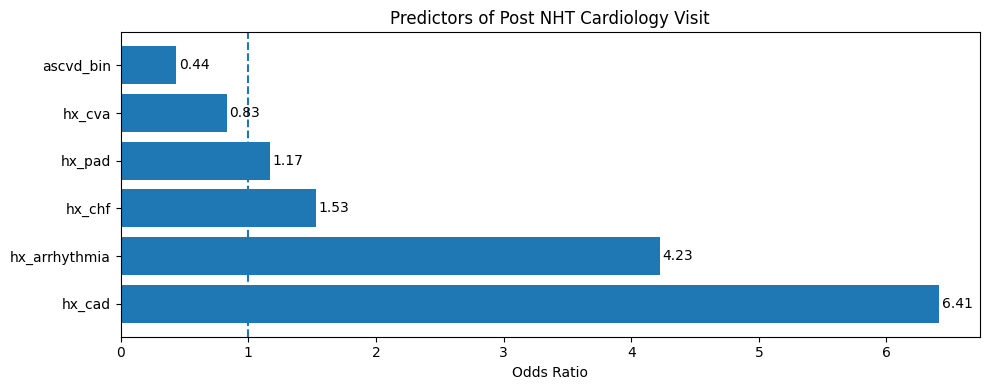

In [18]:
plot_df = post_summary[post_summary["feature"] != "const"].copy()

plt.figure(figsize=(10,4))
bars = plt.barh(plot_df["feature"], plot_df["odds_ratio"])

plt.axvline(1, linestyle="--")
plt.title("Predictors of Post NHT Cardiology Visit")
plt.xlabel("Odds Ratio")
plt.tight_layout()

# add value labels
for i, value in enumerate(plot_df["odds_ratio"]):
    plt.text(
        value + 0.02,
        i,
        f"{value:.2f}",
        va='center'
    )

plt.show()

## Gaps?

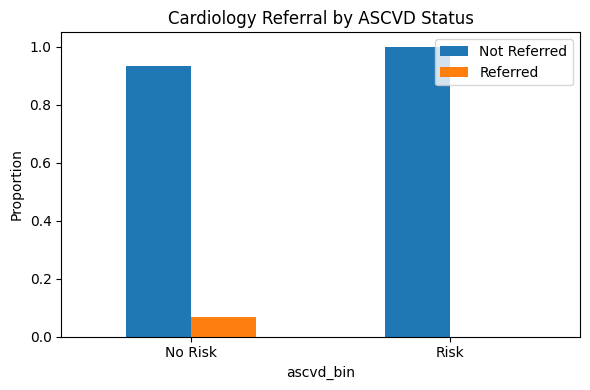

In [19]:
gap = df.groupby("ascvd_bin")["cards_referral_bin"].value_counts(normalize=True).unstack()

gap.plot(kind="bar", figsize=(6,4))
plt.title("Cardiology Referral by ASCVD Status")
plt.ylabel("Proportion")
plt.xticks([0,1], ["No Risk", "Risk"], rotation=0)
plt.legend(["Not Referred", "Referred"])
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["ascvd_bin"], df["cards_referral_bin"])
chi2, p, dof, exp = chi2_contingency(ct)

print(ct)
print("p-value:", p)

cards_referral_bin    0   1
ascvd_bin                  
0                   151  11
1                    41   0
p-value: 0.18367250374363478


### Summary
To evaluate potential gaps in cardiology referral, ASCVD status was defined as a binary indicator (1 = presence of documented ASCVD risk flag, 0 = no recorded risk flag in the dataset). This definition reflects the structure of the available data rather than a continuous or percentile-based risk score.

When comparing referral rates between ASCVD-positive and ASCVD-negative patients, a large proportion of ASCVD-positive patients were not referred to cardiology. However, chi-square testing did not demonstrate a statistically significant association between ASCVD status and referral likelihood, indicating that observed differences in raw proportions are not stable when accounting for sample size and variability.

This suggests that while numerically there appears to be under-referral among patients with documented ASCVD risk, referral patterns are not statistically stratified by ASCVD status in this cohort. The findings support the interpretation that cardiology referral is not systematically driven by ASCVD risk classification, but rather by individual clinical diagnoses.

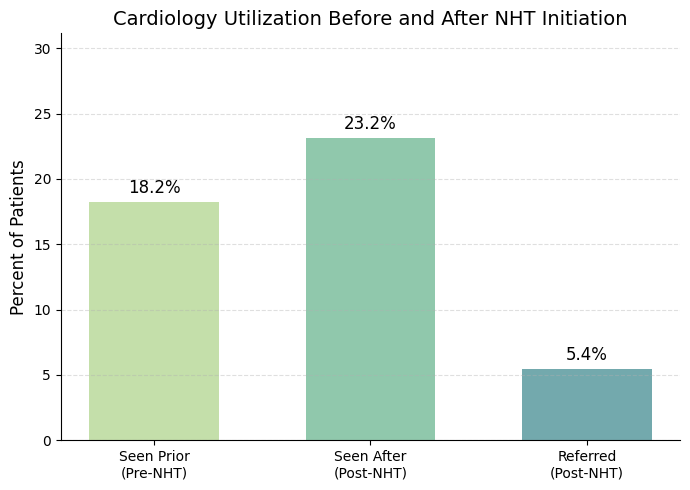

In [ ]:
palette = ["#C4DFAA", "#90C8AC", "#73A9AD"]

util = pd.DataFrame({
    "Stage": [
        "Seen Prior\n(Pre-NHT)",
        "Seen After\n(Post-NHT)",
        "Referred\n(Post-NHT)"
    ],
    "Percent": [
        df["cards_prior_bin"].mean() * 100,
        df["cards_post_bin"].mean() * 100,
        df["cards_referral_bin"].mean() * 100
    ]
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    util["Stage"],
    util["Percent"],
    color=palette,
    width=0.6
)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.7,
        f"{height:.1f}%",
        ha='center',
        fontsize=12,
        #fontweight='bold'
    )

plt.ylabel("Percent of Patients", fontsize=12)

plt.title(
    "Cardiology Utilization Before and After NHT Initiation",
    fontsize=14,
    #fontweight='bold'
)

plt.ylim(0, max(util["Percent"]) + 8)

# Clean styling
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()